In [1]:
import os
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Environment & libraries loaded successfully!")
print(f"yfinance version: {yf.__version__}")

Environment & libraries loaded successfully!
yfinance version: 1.7.0


In [2]:
# ── 1. Load the portfolio spreadsheet ────────────────────────────────────────
portfolio = pd.read_csv('portfolio.csv')
print("=== PORTFOLIO LOADED ===")
print(portfolio.to_string(index=False))

# ── 2. Define date range: exactly 1 year back from today ─────────────────────
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')
print(f"\nFetching market data: {START_DATE} → {END_DATE}")

# ── 3. Pull 1 year of daily closing prices for all tickers ───────────────────
tickers = portfolio['Ticker'].tolist()

raw = yf.download(
    tickers    = tickers,
    start      = START_DATE,
    end        = END_DATE,
    auto_adjust= True,    # adjusts for splits & dividends automatically
    progress   = False
)

# Extract only the 'Close' price columns
prices = raw['Close'].copy()
print(f"\n✅ Price data shape: {prices.shape}  ({prices.shape[0]} trading days × {prices.shape[1]} tickers)")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nMissing values per ticker:\n{prices.isnull().sum().to_string()}")

# ── 4. Forward-fill any

=== PORTFOLIO LOADED ===
Ticker               Company     Sector  Shares  Buy_Price
  AAPL            Apple Inc. Technology      50      175.0
  MSFT       Microsoft Corp. Technology      30      380.0
  NVDA          NVIDIA Corp. Technology      40       95.0
 GOOGL         Alphabet Inc. Technology      35      140.0
   JPM  JPMorgan Chase & Co.    Finance      40      180.0
     V             Visa Inc.    Finance      25      260.0
   BAC Bank of America Corp.    Finance     150       34.0
   JNJ     Johnson & Johnson Healthcare      30      155.0
   PFE           Pfizer Inc. Healthcare     100       28.0
   XOM     Exxon Mobil Corp.     Energy      45      105.0
   CVX         Chevron Corp.     Energy      30      150.0
  AMZN       Amazon.com Inc.   Consumer      40      170.0
    KO         Coca-Cola Co.   Consumer     100       60.0
   MCD      McDonald's Corp.   Consumer      20      280.0
   NKE             Nike Inc.   Consumer      50       95.0

Fetching market data: 2025-09-

In [6]:
# ── 1. Diagnose where the NaN values actually are ────────────────────────────
null_locations = prices[prices.isnull().any(axis=1)]
print(f"NaN found in {len(null_locations)} row(s):")
print(null_locations.index.tolist())
print(f"\nFirst row of prices: {prices.index[0].date()}")
print(f"Last row of prices:  {prices.index[-1].date()}")

# ── 2. Fix: drop the incomplete row entirely ──────────────────────────────────
# 1 row out of 251 = 0.4% data loss — completely acceptable for annual analysis
prices.dropna(inplace=True)

remaining_nulls = prices.isnull().sum().sum()
assert remaining_nulls == 0, f"❌ Still {remaining_nulls} NaN values!"
print(f"\n✅ Data Quality Check PASSED — Zero NaN values after dropping incomplete row")
print(f"   Final shape: {prices.shape}  ({prices.shape[0]} clean trading days × {prices.shape[1]} tickers)")

# ── 3. Recompute portfolio KPIs using the now-clean latest price ──────────────
latest_prices = prices.iloc[-1]
portfolio['Current_Price'] = portfolio['Ticker'].map(latest_prices)
portfolio['Cost_Basis']    = portfolio['Shares'] * portfolio['Buy_Price']
portfolio['Market_Value']  = portfolio['Shares'] * portfolio['Current_Price']
portfolio['PnL_Dollar']    = portfolio['Market_Value'] - portfolio['Cost_Basis']
portfolio['PnL_Pct']       = ((portfolio['Current_Price'] - portfolio['Buy_Price']) / portfolio['Buy_Price'] * 100).round(2)

# ── 4. Compute daily returns ──────────────────────────────────────────────────
daily_returns = prices.pct_change(fill_method=None).dropna() * 100
print(f"✅ Daily returns computed: {daily_returns.shape}")

# ── 5. Summary statistics ─────────────────────────────────────────────────────
print("\n=== DAILY RETURN STATISTICS (%) ===")
stats = daily_returns.describe().T[['mean', 'std', 'min', 'max']].round(3)
stats.columns = ['Mean Daily %', 'Std Dev %', 'Worst Day %', 'Best Day %']
print(stats.to_string())

# ── 6. Spot-check P&L assertion ───────────────────────────────────────────────
aapl_row     = portfolio[portfolio['Ticker'] == 'AAPL'].iloc[0]

NaN found in 1 row(s):
[Timestamp('2026-09-22 00:00:00')]

First row of prices: 2025-09-23
Last row of prices:  2026-09-22

✅ Data Quality Check PASSED — Zero NaN values after dropping incomplete row
   Final shape: (250, 15)  (250 clean trading days × 15 tickers)
✅ Daily returns computed: (249, 15)

=== DAILY RETURN STATISTICS (%) ===
        Mean Daily %  Std Dev %  Worst Day %  Best Day %
Ticker                                                  
AAPL           0.129      1.549       -7.354       4.841
AMZN           0.086      2.170       -5.555      15.321
BAC            0.064      1.386       -5.136       4.372
CVX            0.130      1.509       -4.587       5.099
GOOGL          0.159      1.991       -7.133       9.962
JNJ            0.186      1.198       -3.657       3.994
JPM            0.065      1.400       -4.664       3.946
KO             0.125      1.184       -3.957       4.996
MCD           -0.064      1.173       -3.410       4.157
MSFT           0.018      2.057    

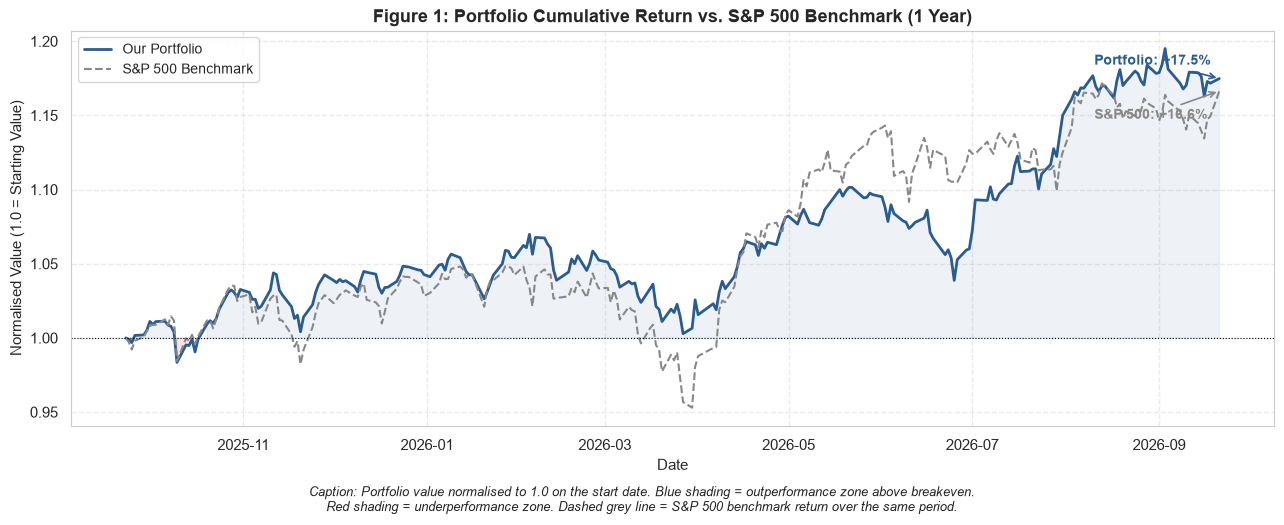


Portfolio 1-Year Return : +17.48%
S&P 500  1-Year Return  : +16.64%
Alpha (vs benchmark)    : +0.84%


In [8]:
# ── Benchmark: Fetch S&P 500 (ticker: ^GSPC) for the same period ─────────────
sp500_raw = yf.download('^GSPC', start=prices.index[0], end=prices.index[-1] + timedelta(days=1),
                         auto_adjust=True, progress=False)
sp500 = sp500_raw['Close'].squeeze()
sp500 = sp500.reindex(prices.index).ffill().dropna()

# ── Compute cumulative portfolio value over time ──────────────────────────────
# Weight each stock by its initial cost basis as a fraction of total portfolio
total_cost    = portfolio['Cost_Basis'].sum()
weights       = portfolio.set_index('Ticker')['Cost_Basis'] / total_cost  # fraction of portfolio per ticker

# Normalise prices to 1.0 on day 0, then weight-sum to get portfolio index
norm_prices   = prices / prices.iloc[0]                # each stock = 1.0 on start date
portfolio_idx = norm_prices.mul(weights, axis=1).sum(axis=1)  # weighted average

# Normalise S&P 500 to 1.0 on same start date
sp500_idx     = sp500 / sp500.iloc[0]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(portfolio_idx.index, portfolio_idx, color='#2b5c8f', linewidth=2,    label='Our Portfolio')
ax.plot(sp500_idx.index,     sp500_idx,     color='#888888', linewidth=1.5,
        linestyle='--', label='S&P 500 Benchmark')

ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':')
ax.fill_between(portfolio_idx.index, 1.0, portfolio_idx,
                where=(portfolio_idx >= 1.0), alpha=0.08, color='#2b5c8f')
ax.fill_between(portfolio_idx.index, 1.0, portfolio_idx,
                where=(portfolio_idx < 1.0),  alpha=0.12, color='#d73027')

# Annotate final values
final_port  = portfolio_idx.iloc[-1]
final_sp500 = sp500_idx.iloc[-1]
ax.annotate(f'Portfolio: {(final_port-1)*100:+.1f}%',
            xy=(portfolio_idx.index[-1], final_port),
            xytext=(-90, 10), textcoords='offset points',
            fontsize=10, color='#2b5c8f', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2b5c8f', lw=1.2))
ax.annotate(f'S&P 500: {(final_sp500-1)*100:+.1f}%',
            xy=(sp500_idx.index[-1], final_sp500),
            xytext=(-90, -20), textcoords='offset points',
            fontsize=10, color='#888888', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2))

ax.set_title("Figure 1: Portfolio Cumulative Return vs. S&P 500 Benchmark (1 Year)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Normalised Value (1.0 = Starting Value)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.figtext(0.5, -0.04,
    "Caption: Portfolio value normalised to 1.0 on the start date. Blue shading = outperformance zone above breakeven.\n"
    "Red shading = underperformance zone. Dashed grey line = S&P 500 benchmark return over the same period.",
    ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print(f"\nPortfolio 1-Year Return : {(final_port  - 1)*100:+.2f}%")
print(f"S&P 500  1-Year Return  : {(final_sp500 - 1)*100:+.2f}%")
print(f"Alpha (vs benchmark)    : {(final_port - final_sp500)*100:+.2f}%")